<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/nprivaul/fractionalpdes/blob/master/multiple_simulations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

This code solves the time-fractional F-KPP equation
$$\partial_t^\alpha u=-(-\Delta u)^{\gamma/2}-\lambda u+\lambda (p_0+p_1 u+ \cdots +p_N u^N)$$ 
on the whole space $R^d$ with initial condition $f$, $\lambda>0$, $p_k\in [0,1]$, $p_0+ \cdots +p_N=1$, $\alpha = 0.5$ and $\gamma =2$. 

In [1]:
import math
import matplotlib.pyplot as plt
from scipy.stats import expon,uniform,norm
import numpy as np
from scipy.special import lambertw

plt.rcParams.update({
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 16,
    "legend.title_fontsize": 14,
    "xtick.major.pad": 8,        # Increase distance between x-axis and tick labels (default ~4)
    "figure.titlesize": 24,
    "axes.xmargin": 0,      # Equivalent to ax.margins(x=0)
    "figure.autolayout": True,  # Equivalent to plt.tight_layout()
})

In [2]:
# -*- coding: utf-8 -*-
"""
Created on Mon Mar 16 04:40:13 2026

@author: gerar
"""

#=============================================================================
#MC ALGORITHM
#=============================================================================
def f(x,d): 
    """
    Initial condition - a function from R^d to [0,1]
    x=[x[1],...,x[d]] is an array if d>1; if d=1, x must be a float
    """
    if d==1:
        return 1*(0.5+np.arctan(1000*x)/np.pi)  
    else:
        # For 2D/3D, use radially symmetric initial condition
        r_squared = sum(x_i**2 for x_i in x)
        return 0.5 + np.arctan(1000 * (1 - np.sqrt(r_squared))) / np.pi
    
def subordinator_rv(alpha):
    """
    This simulates S(1), where (S(t))_T is an \alpha-stable subordinator (Chambers, Mallows, Stuck (1976))
    alpha is a number in (0,1]
    """
    if alpha==1:
        return 1
    else:
        theta=math.pi*uniform.rvs()
        w=expon.rvs()
        aux1=(math.sin((1-alpha)*theta)/w)**((1-alpha)/alpha)
        aux2=math.sin(alpha*theta)/math.sin(theta)**(1/alpha)
        return aux1*aux2
    
def stable_rv(gamma,d,t):
    """
    This simulates X(t), where (X(t))_t is a d-dimensional symmetric gamma-stable process
    gamma is a number in (0,2], d is a natural number, t geq 0
    If d==1, the output is a float; if d>1, it is an array 
    """
    if d==1:
        return norm.rvs()*(2*subordinator_rv(gamma/2))**(1/2)*t**(1/gamma)  #Scaling property
    else:
       aux1=norm.rvs(size=d)
       aux2=subordinator_rv(gamma/2)
       return [aux1[i]*(2*aux2)**(1/2)*t**(1/gamma) for i in range(d)]
   
def discrete_rv(p):
    """
    This simulates a random variable on {0,1,..., N}, N>1, according to law [p_0,p_1,...,p_N]
    p_k is a number in [0,1] and p_0+p_1+...+p_N=1
    """
    aux=0
    u=uniform.rvs()
    for i in range(len(p)):
        if u<aux+p[i]:
            return i
        else:
            aux=aux+p[i]
    
def branching(alpha,gamma,lam,p,d,x,T):
    """
    This simulates the random variable V= prod_{k in mathcal{N}_t^alpha}f(x+Y_k^alpha(t))
    alpha,gam,lam,p,d are as in the section "PARAMETERS"
    x=[x[1],...,x[d]] is an array representing a point, T is a positive number representing time
    """
    s1=subordinator_rv(alpha)
    tau=expon.rvs()/lam                             #Exponential lifetime 
    sigma=s1*tau**(1/alpha)                         #Mittag Leffler lifetime
    if sigma>T:                                     #No branching case
        et=(T/s1)**alpha                            #Inverse stable subordinator law
        dx=stable_rv(gamma,d,et)                    #Spatial displacement
        if d==1:                                    #Dimension one case
            Y=x+dx                                  #Position at branching time
            return f(Y,d)
        else:                                       #Dimension greater than one
            Y=[x[i]+dx[i] for i in range(d)]
            return f(Y,d)
    else:                                           #Branching case
        branches=discrete_rv(p)                     #Number of branches
        aux=1
        dx=stable_rv(gamma,d,tau)                   
        if d==1:
            Y=x+dx
            for i in range(branches):
                aux=aux*branching(alpha,gamma,lam,p,d,Y,T-sigma)    #Recursion
            return aux 
        else:
            Y=[x[i]+dx[i] for i in range(d)]
            for i in range(branches):
                aux=aux*branching(alpha,gamma,lam,p,d,Y,T-sigma) 
            return aux
            
def mc_kpp_sol(alpha,gamma,lam,p,d,x,T,n_iter):           
    """
    This is the Monte Carlo estimator of the solution at (x,T)
    alpha,gam,lam,p,d are as in the section "Parameters"
    n_iter is the sample size
    """       
    aux=0
    for i in range(n_iter):
        aux=aux+branching(alpha,gamma,lam,p,d,x,T)
    return aux/n_iter               #MC estimator

#==============================================================================
#MULTIPLE SIMULATIONS d=1
#==============================================================================
#PARAMETERS
alpha=0.5   #time-fractional order alpha - a number in (0,1]
gamma=2     #space-fractional order gamma - a number in (0,2]
lam=1.0     #\lambda - a strictly positive constant
p=[0,0,1]   #probability density [p_0,p_1,...,p_N] corresponding to the polynomial non-linearity - it satisfies p_k in[0,1] and p_0+p_1+...+p_N=1
d=1         #dimension - a natural number
T=0.5           #maximum time - a positive number
n_iter=1026     #sample size for Monte Carlo estimator - a natural number (reduced for speed)
a=-10           #[a,b] is interval of simulation - a<b, a,b are any reals
b=10
nx=21               #number of points in [a,b] - a natural number

x = [a+i*(b-a)/(nx-1) for i in range(nx)]    #space discretization

n_sim=10                                    #number of simulations
y=[[0 for i in range(nx)] for j in range(n_sim)]
sd=[0 for i in range(1,n_iter)]
mean_X=[0 for i in range(nx)]
result=[0 for i in range(nx)]

# #MC estimator and plots
# #plt.figure(figsize=(10, 6))
# for ii in range(1,n_iter,50):
#     for i in range(n_sim):
#         for j in range(nx):
#             y[i][j]=mc_kpp_sol(alpha, gamma, lam, p, d, x[j], T, ii)
#     print(f"Progress: {ii+1}/{n_iter}") # " - {i+1}/{n_sim}")
# #    plt.plot(x, y[i], '-', label = 'Multiple paths', linewidth=2)  
# #    plt.plot(x, y[i], '-', label = '', linewidth=2)   
# #Standard deviation
#     for j in range(nx):
#         mean_X[j] = np.mean([y[i][j] for i in range(n_sim)])
#         result[j] = np.mean(np.abs(([y[i][j] for i in range(n_sim)]) - mean_X[j]))
# #    print(result)
#     sd[ii]=max(result[j] for j in range(nx))
import numpy as np
from multiprocessing import Pool, cpu_count

def worker(args):
    i, j, ii = args
    return i, j, mc_kpp_sol(alpha, gamma, lam, p, d, x[j], T, ii)

if __name__ == "__main__":

    y = np.zeros((n_sim, nx))
    mean_X = np.zeros(nx)
    result = np.zeros(nx)
    sd = np.zeros(n_iter)

    print(f"Using {cpu_count()} CPU cores for {len(range(1, n_iter, 50))} iterations x {n_sim*nx} points each...")

    with Pool(cpu_count()) as pool:
        for ii in range(1, n_iter, 25):
            # prepare arguments for all i,j
            args = [(i, j, ii) for i in range(n_sim) for j in range(nx)]
            
            # map in parallel
            for i, j, val in pool.imap(worker, args):
                y[i, j] = val

            # compute mean and mean-absolute deviation
            for j in range(nx):
                col = y[:, j]
                mean_X[j] = np.mean(col)
                result[j] = np.mean(np.abs(col - mean_X[j]))
            sd[ii] = np.max(result)

            print(f"Completed iteration ii={ii}/{n_iter}")

Using 8 CPU cores for 21 iterations x 210 points each...
Completed iteration ii=1/1026
Completed iteration ii=26/1026
Completed iteration ii=51/1026
Completed iteration ii=76/1026
Completed iteration ii=101/1026
Completed iteration ii=126/1026
Completed iteration ii=151/1026
Completed iteration ii=176/1026
Completed iteration ii=201/1026
Completed iteration ii=226/1026
Completed iteration ii=251/1026
Completed iteration ii=276/1026
Completed iteration ii=301/1026
Completed iteration ii=326/1026
Completed iteration ii=351/1026
Completed iteration ii=376/1026
Completed iteration ii=401/1026
Completed iteration ii=426/1026
Completed iteration ii=451/1026
Completed iteration ii=476/1026
Completed iteration ii=501/1026
Completed iteration ii=526/1026
Completed iteration ii=551/1026
Completed iteration ii=576/1026
Completed iteration ii=601/1026
Completed iteration ii=626/1026
Completed iteration ii=651/1026
Completed iteration ii=676/1026
Completed iteration ii=701/1026
Completed iteration 

/tmp/ipykernel_3029038/2392893013.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  bound=[(0.5/math.sqrt(n_points[i]))*(1/math.sqrt(-lambertw(-1/(16*n_points[i]),k=-1))+math.sqrt(-lambertw(-1/(16*n_points[i]),k=-1)))for i in range(num_points)]


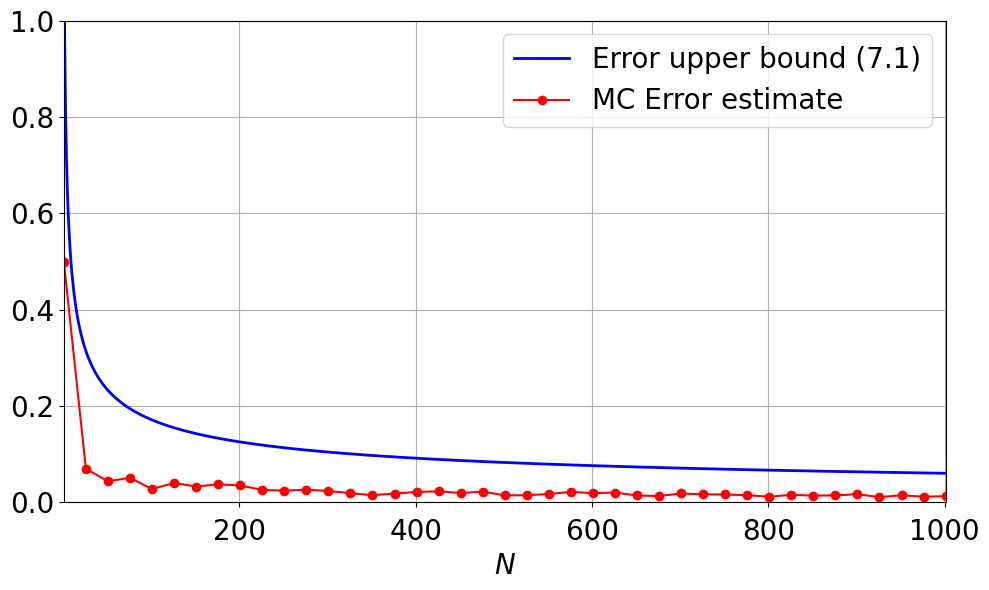

In [10]:
# plt.title(f"1D Time-Fractional F-KPP Equation at t={T}, max SD={np.round(sd,4)}")
#plt.xlabel(r"$x$")
# plt.ylabel(r"$v(t,x)$")
#plt.ylim(-0.001,1.001)
#plt.legend()
#plt.grid(True, alpha=0.3)
#plt.savefig('multiple_kpp.png', format='png', dpi=150)
#plt.show()

#===============================================================================
#BOUND FOR L^1 convergence
#==============================================================================
n_max=1000
num_points=1000
n_points=[n_max*(i+1)/num_points for i in range(num_points)]
bound=[(0.5/math.sqrt(n_points[i]))*(1/math.sqrt(-lambertw(-1/(16*n_points[i]),k=-1))+math.sqrt(-lambertw(-1/(16*n_points[i]),k=-1)))for i in range(num_points)]

#Plot results
# plt.figure(figsize=(10, 6))
#plt.plot(n_points, bound, '-', label = "E"r"$|\hat{v}_N(t,x)-v(t,x)|$", linewidth=2)
idx = range(1, 1025, 25)
#plt.plot([i for i in idx], [sd[i] for i in idx], linestyle='-',marker='.',color='red',markersize=12,markevery=1,lw=1.5,label = "MC Error estimate")
# plt.title(f"Upper bound for convergence in "r"$L^1(\Omega)$")
#plt.xlabel(r"$N$")
# plt.ylabel("E"r"$|\hat{v}_N(t,x)-v(t,x)|$")
#plt.ylim(-0.001,1.001)
#plt.legend()
#plt.grid(True, alpha=0.3)
#plt.savefig('l1bound.png', format='png', dpi=150)
#plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
# ax.plot(n_points, bound, '-', label = "E"r"$|\hat{v}_N(t,x)-v(t,x)|$", color='blue',linewidth=2)
ax.plot(n_points, bound, '-', label = "Error upper bound (7.1)", color='blue',linewidth=2)
ax.plot([i for i in range(1, 1025, 25)], [sd[i] for i in range(1, 1025, 25)], linestyle='-',marker='.',color='red',markersize=12,markevery=1,lw=1.5,label = "MC Error estimate")
ax.set_xlabel(r"$N$")
ax.margins(x=0)
ax.legend(loc="upper right", fontsize=20)
ax.set_ylim(-0.001, 1.001)
plt.tight_layout()
# ax.set_xticks(xx_arr)
ax.grid(True)
fig.savefig('l1bound.pdf', bbox_inches="tight")